# Proyecto Integrador - Minería de Datos I

**Notebook 03: Análisis Exploratorio de Datos (EDA)**



**Objetivo**

El objetivo de este notebook es explorar el conjunto de datos previamente preparado para identificar patrones, relaciones y comportamientos relevantes entre las variables.

Cada análisis realizado responde a una pregunta específica y se acompaña de una interpretación basada en la evidencia obtenida, permitiendo comprender mejor las características del conjunto de datos antes de aplicar técnicas de reducción de dimensionalidad.

In [1]:
# Importación de librerías

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:.2f}".format

In [2]:
# Carga del dataset limpio

ruta = "/content/drive/MyDrive/PI_Mineria_Datos_1/data/processed/streaming_users_clean.csv"

df = pd.read_csv(ruta)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [3]:
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.00,Estándar,805.80,Brasil,Crimen,2025-03-04,2.50
1,10001,37.00,Estándar,1173.40,Colombia,Crimen,2019-04-02,2.00
2,10002,28.00,Básico,401.00,Colombia,Crimen,2018-04-13,0.00
3,10003,43.00,Básico,62.40,Uruguay,Thriller,2021-01-31,0.00
4,10004,51.00,Básico,477.80,Perú,Thriller,2020-09-30,1.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8034 entries, 0 to 8033
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8034 non-null   int64  
 1   age                       8034 non-null   float64
 2   subscription_plan         8034 non-null   object 
 3   monthly_watch_time_mins   8034 non-null   float64
 4   country                   8034 non-null   object 
 5   favorite_genre            8034 non-null   object 
 6   last_login_date           7250 non-null   object 
 7   customer_support_tickets  8034 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 502.3+ KB


# Preguntas de análisis

El análisis exploratorio se desarrollará a partir de las siguientes preguntas:

1. ¿Cuál es el plan de suscripción más utilizado por los usuarios?

2. ¿Cómo se distribuye el tiempo mensual de visualización?

3. ¿Existen diferencias en el tiempo de visualización según el plan contratado?

4. ¿Existe relación entre la edad de los usuarios y el tiempo mensual de visualización?

5. ¿Qué relación presentan las variables numéricas del conjunto de datos?

# Análisis Univariado 1

## Pregunta

¿Cuál es el plan de suscripción más utilizado por los usuarios?

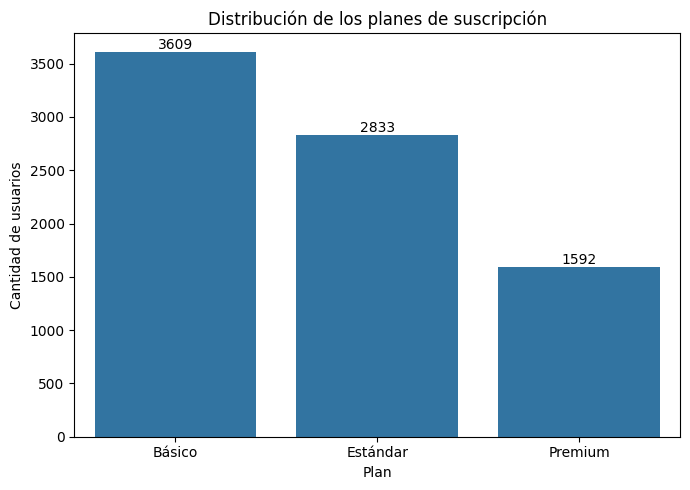

In [5]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="subscription_plan",
    order=df["subscription_plan"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribución de los planes de suscripción")
plt.xlabel("Plan")
plt.ylabel("Cantidad de usuarios")

plt.tight_layout()
plt.show()

### Interpretación

Se observa que el plan **Básico** es el más utilizado por los usuarios, seguido por el plan **Estándar**, mientras que el plan **Premium** presenta la menor cantidad de suscripciones.

Esta distribución indica que la mayoría de los usuarios opta por las alternativas de menor costo, lo que podría estar relacionado con sus preferencias o con la estrategia comercial de la plataforma.

# Análisis univariado 2
## Pregunta

¿Cómo se distribuye el tiempo mensual de visualización?

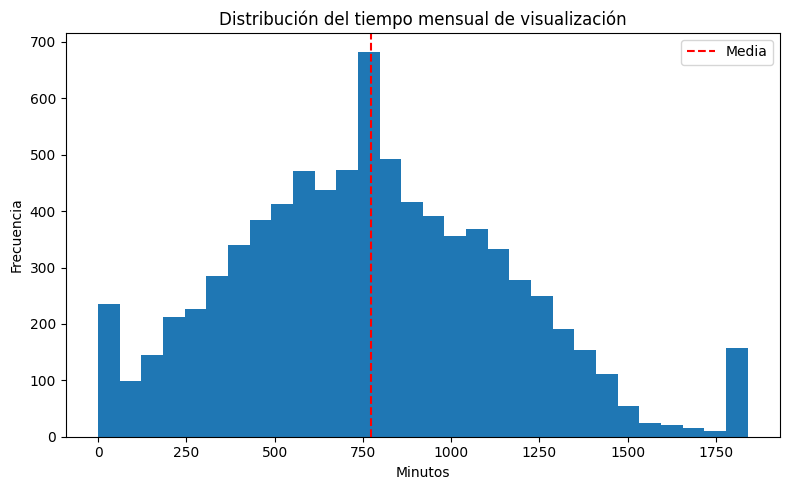

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    df["monthly_watch_time_mins"],
    bins=30
)

plt.axvline(
    df["monthly_watch_time_mins"].mean(),
    color="red",
    linestyle="--",
    label="Media"
)

plt.title("Distribución del tiempo mensual de visualización")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")

plt.legend()

plt.tight_layout()
plt.show()

### Interpretación

La mayor concentración de usuarios registra entre aproximadamente 500 y 1000 minutos de visualización mensual.

La distribución presenta una ligera asimetría hacia la derecha, indicando que existen usuarios con consumos superiores al promedio, aunque representan una proporción menor del conjunto de datos.

# Bivariado 1
## Pregunta

¿Existen diferencias en el tiempo de visualización según el plan contratado?

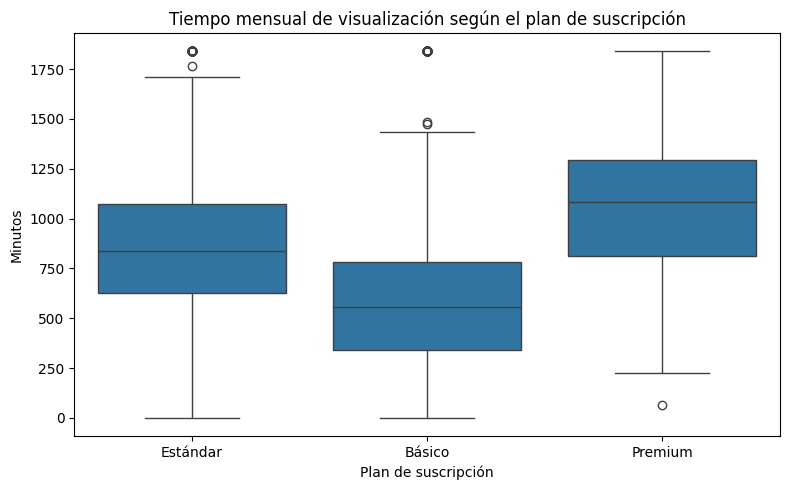

In [7]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="subscription_plan",
    y="monthly_watch_time_mins"
)

plt.title("Tiempo mensual de visualización según el plan de suscripción")
plt.xlabel("Plan de suscripción")
plt.ylabel("Minutos")

plt.tight_layout()
plt.show()

### Interpretación

Se observan diferencias en el tiempo mensual de visualización según el plan de suscripción.

Los usuarios con plan **Premium** presentan, en general, un mayor tiempo de visualización, mientras que los usuarios del plan **Básico** muestran los valores más bajos. El plan **Estándar** presenta un comportamiento intermedio.

Estos resultados sugieren una posible asociación entre el tipo de suscripción y el consumo de contenido en la plataforma.

# Bivariado 2
## Pregunta

¿Existe relación entre la edad de los usuarios y el tiempo mensual de visualización?

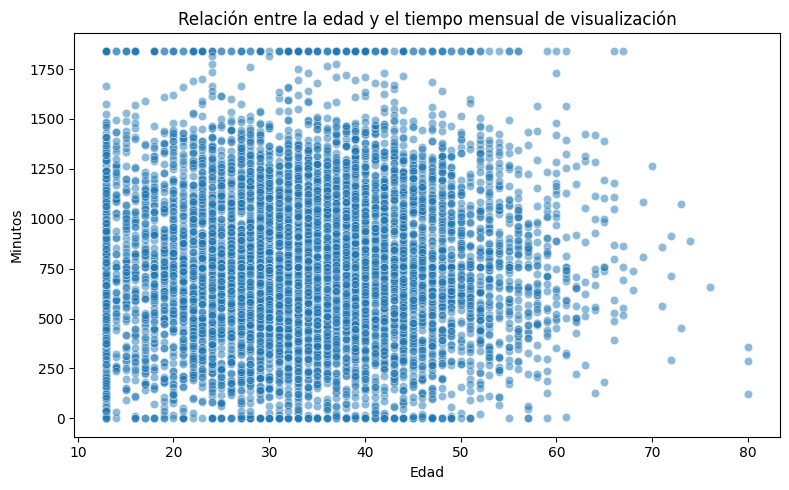

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="monthly_watch_time_mins",
    alpha=0.5
)

plt.title("Relación entre la edad y el tiempo mensual de visualización")
plt.xlabel("Edad")
plt.ylabel("Minutos")

plt.tight_layout()
plt.show()

### Interpretación

La distribución de los puntos no evidencia una relación lineal clara entre la edad de los usuarios y el tiempo mensual de visualización.

Los niveles de consumo se mantienen distribuidos de forma similar en la mayoría de las edades, por lo que la edad, por sí sola, no parece explicar el tiempo dedicado al consumo de contenido.

# Multivariado
## Pregunta

¿Qué relación presentan las variables numéricas del conjunto de datos?

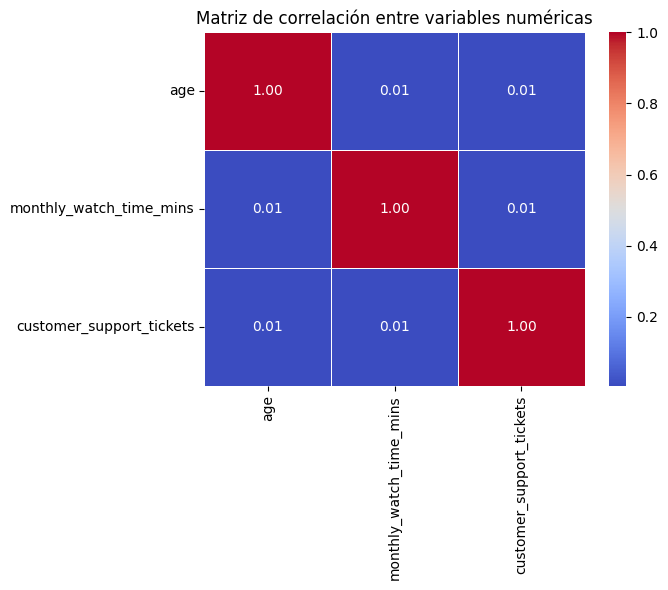

In [9]:
variables_numericas = [
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets"
]

correlacion = df[variables_numericas].corr()

plt.figure(figsize=(7,6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")

plt.tight_layout()

plt.show()

### Interpretación

La matriz de correlación muestra que las variables numéricas presentan coeficientes de correlación muy bajos, cercanos a cero.

Esto indica que no existe una relación lineal significativa entre la edad de los usuarios, el tiempo mensual de visualización y la cantidad de tickets de soporte. En consecuencia, cada una de estas variables aporta información diferente al análisis.

Estos resultados servirán como referencia para la aplicación del Análisis de Componentes Principales (PCA), donde se evaluará si es posible representar la información mediante un menor número de componentes.

# Conclusiones del análisis exploratorio

A partir del análisis exploratorio realizado se identificó que:

- El plan **Básico** es el más utilizado por los usuarios.
- La mayor parte del tiempo mensual de visualización se concentra entre aproximadamente **500 y 1000 minutos**.
- Los usuarios con plan **Premium** presentan, en general, un mayor tiempo de visualización que los usuarios de los demás planes.
- No se observó una relación lineal clara entre la edad de los usuarios y el tiempo mensual de visualización.
- Las variables numéricas presentan correlaciones bajas entre sí, lo que indica una escasa relación lineal.

En conjunto, estos resultados permiten comprender mejor el comportamiento de los usuarios y constituyen una base para la aplicación del **Análisis de Componentes Principales (PCA)**, con el fin de explorar la estructura de las variables numéricas y evaluar la posibilidad de reducir la dimensionalidad del conjunto de datos.